# Knapsack Problem Varyasyonları ve Karşılaştırmalı Sistem

Bu projede üç farklı Knapsack problemi karşılaştırılmıştır:

1. 0/1 Knapsack - Dynamic Programming
2. Unbounded Knapsack - Dynamic Programming
3. Fractional Knapsack - Greedy Algorithm

Amaç, aynı veri seti üzerinde algoritmaların çözüm kalitesi, çalışma süresi, kararlılık, hesaplama maliyeti ve ölçeklenebilirlik açısından karşılaştırılmasıdır.

### Gerekli Kütüphaneler

In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Sabit Rastgelelik

In [2]:
random.seed(42)
np.random.seed(42)

### Veri Üretme Fonksiyonu

In [3]:
def generate_random_data(n_items, min_weight=5, max_weight=50, min_value=20, max_value=200):
    weights = [random.randint(min_weight, max_weight) for _ in range(n_items)]
    values = [random.randint(min_value, max_value) for _ in range(n_items)]
    return weights, values

### Ana Veri Seti

In [4]:
n_items = 20
capacity = 100

weights, values = generate_random_data(n_items)

items = [f"Item {i+1}" for i in range(n_items)]

data = pd.DataFrame({
    "Item": items,
    "Weight": weights,
    "Value": values,
    "Value/Weight": [round(v / w, 2) for v, w in zip(values, weights)]
})

data

,Item,Weight,Value,Value/Weight
0,Item 1,45,26,0.58
1,Item 2,12,163,13.58
2,Item 3,6,70,11.67
3,Item 4,22,186,8.45
4,Item 5,20,199,9.95
5,Item 6,19,159,8.37
6,Item 7,13,127,9.77
7,Item 8,11,76,6.91
8,Item 9,48,134,2.79
9,Item 10,39,170,4.36


Bu çalışmada 20 ürün ve 100 kapasite kullanılmıştır.

Her ürünün:
- ağırlığı,
- değeri,
- değer/ağırlık oranı

hesaplanmıştır.


## 0/1 Knapsack

0/1 Knapsack probleminde her ürün ya tamamen seçilir ya da hiç seçilmez.

Aynı üründen birden fazla alınamaz.

Bu problem Dynamic Programming yöntemiyle çözülür.

Zaman karmaşıklığı:

O(n × W)

Burada:
- n: ürün sayısı
- W: kapasite

In [5]:
def zero_one_knapsack(weights, values, capacity):
    n = len(weights)

    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i - 1] <= w:
                include_item = values[i - 1] + dp[i - 1][w - weights[i - 1]]
                exclude_item = dp[i - 1][w]
                dp[i][w] = max(include_item, exclude_item)
            else:
                dp[i][w] = dp[i - 1][w]

    selected_items = []
    w = capacity

    for i in range(n, 0, -1):
        if dp[i][w] != dp[i - 1][w]:
            selected_items.append(i - 1)
            w -= weights[i - 1]

    selected_items.reverse()

    return dp[n][capacity], selected_items

## Unbounded Knapsack

Unbounded Knapsack probleminde her üründen sınırsız sayıda seçilebilir.

Yani aynı ürün çantaya birden fazla kez eklenebilir.

Bu problem de Dynamic Programming yöntemiyle çözülür.

Zaman karmaşıklığı:

O(n × W)

In [6]:
def unbounded_knapsack(weights, values, capacity):
    n = len(weights)

    dp = [0 for _ in range(capacity + 1)]
    selected = [-1 for _ in range(capacity + 1)]

    for w in range(capacity + 1):
        for i in range(n):
            if weights[i] <= w:
                candidate_value = dp[w - weights[i]] + values[i]

                if candidate_value > dp[w]:
                    dp[w] = candidate_value
                    selected[w] = i

    selected_items = []
    w = capacity

    while w > 0 and selected[w] != -1:
        item_index = selected[w]
        selected_items.append(item_index)
        w -= weights[item_index]

    return dp[capacity], selected_items

## Fractional Knapsack

Fractional Knapsack probleminde ürünler parçalı olarak seçilebilir.

Bu yöntemde ürünler değer/ağırlık oranına göre sıralanır.

En yüksek orana sahip ürünlerden başlanarak kapasite doldurulur.

Bu problem Greedy Algorithm ile çözülür.

Zaman karmaşıklığı:

O(n log n)

In [7]:
def fractional_knapsack(weights, values, capacity):
    n = len(weights)

    item_list = []

    for i in range(n):
        item_list.append({
            "index": i,
            "weight": weights[i],
            "value": values[i],
            "ratio": values[i] / weights[i]
        })

    item_list.sort(key=lambda x: x["ratio"], reverse=True)

    total_value = 0
    selected_items = []
    remaining_capacity = capacity

    for item in item_list:
        if remaining_capacity == 0:
            break

        if item["weight"] <= remaining_capacity:
            total_value += item["value"]
            remaining_capacity -= item["weight"]

            selected_items.append({
                "index": item["index"],
                "fraction": 1
            })
        else:
            fraction = remaining_capacity / item["weight"]
            total_value += item["value"] * fraction

            selected_items.append({
                "index": item["index"],
                "fraction": fraction
            })

            remaining_capacity = 0

    return total_value, selected_items

### Süre Ölçme Fonksiyonu

In [8]:
def measure_time(func, weights, values, capacity, repeat=1000):
    start = time.perf_counter()

    for _ in range(repeat):
        func(weights, values, capacity)

    end = time.perf_counter()

    return (end - start) / repeat

### Algoritmaları Çalıştırma

In [9]:
result_01, selected_01 = zero_one_knapsack(weights, values, capacity)
result_unbounded, selected_unbounded = unbounded_knapsack(weights, values, capacity)
result_fractional, selected_fractional = fractional_knapsack(weights, values, capacity)

time_01 = measure_time(zero_one_knapsack, weights, values, capacity)
time_unbounded = measure_time(unbounded_knapsack, weights, values, capacity)
time_fractional = measure_time(fractional_knapsack, weights, values, capacity)

print("0/1 Knapsack Result:", result_01)
print("Unbounded Knapsack Result:", result_unbounded)
print("Fractional Knapsack Result:", result_fractional)

print("\n0/1 Knapsack Time:", time_01)
print("Unbounded Knapsack Time:", time_unbounded)
print("Fractional Knapsack Time:", time_fractional)

0/1 Knapsack Result: 1199
Unbounded Knapsack Result: 2772
Fractional Knapsack Result: 1218.2727272727273

0/1 Knapsack Time: 0.0006073382099998526
Unbounded Knapsack Time: 0.0001980177499999627
Fractional Knapsack Time: 9.774853999942935e-06


### Sonuç Tablosu

In [10]:
results_df = pd.DataFrame({
    "Algorithm": [
        "0/1 Knapsack DP",
        "Unbounded Knapsack DP",
        "Fractional Knapsack Greedy"
    ],
    "Maximum Value": [
        result_01,
        result_unbounded,
        round(result_fractional, 2)
    ],
    "Execution Time (seconds)": [
        time_01,
        time_unbounded,
        time_fractional
    ],
    "Time Complexity": [
        "O(n × W)",
        "O(n × W)",
        "O(n log n)"
    ]
})

results_df

,Algorithm,Maximum Value,Execution Time (seconds),Time Complexity
0,0/1 Knapsack DP,1199.00,0.000607,O(n × W)
1,Unbounded Knapsack DP,2772.00,0.000198,O(n × W)
2,Fractional Knapsack Greedy,1218.27,0.000010,O(n log n)


### Maksimum Değer Karşılaştırma Grafiği

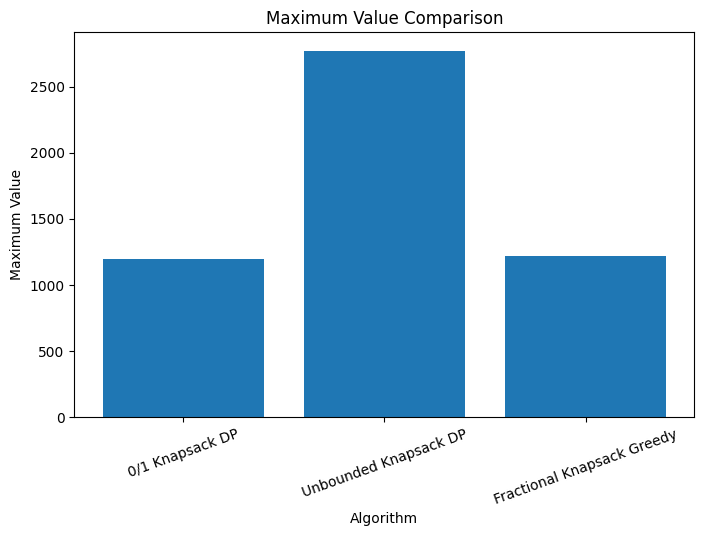

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Algorithm"], results_df["Maximum Value"])
plt.title("Maximum Value Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Maximum Value")
plt.xticks(rotation=20)
plt.show()

Maximum Value karşılaştırmasına göre Unbounded Knapsack algoritması en yüksek çözüm değerini elde etmiştir. Bunun temel nedeni aynı üründen birden fazla seçime izin vermesidir. Fractional Knapsack algoritması ürünleri parçalayabildiği için 0/1 Knapsack'tan biraz daha yüksek çözüm kalitesi üretmiştir. Sonuçlar algoritmaların problem varsayımlarındaki farklılığın çözüm kalitesini doğrudan etkilediğini göstermektedir.

### Çalışma Süresi Karşılaştırma Grafiği

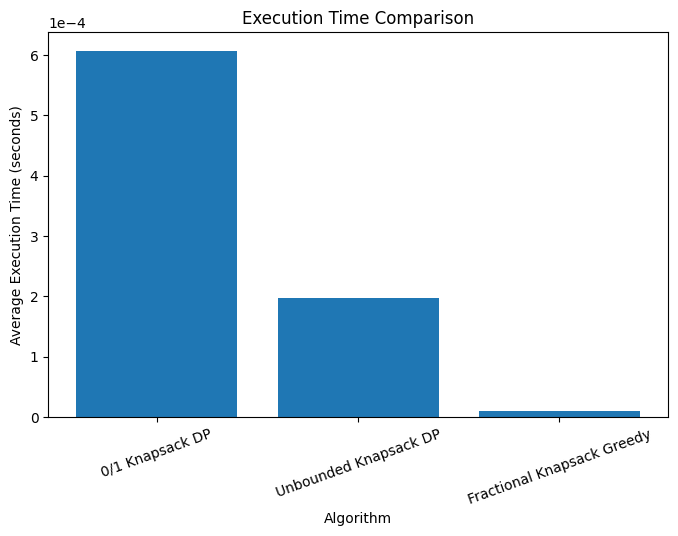

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Algorithm"], results_df["Execution Time (seconds)"])
plt.title("Execution Time Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Average Execution Time (seconds)")
plt.xticks(rotation=20)
plt.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
plt.show()

Çalışma süresi karşılaştırmasında Fractional Knapsack algoritması en düşük süreyi göstermiştir. Bunun nedeni greedy yaklaşım kullanması ve daha düşük hesaplama maliyetine sahip olmasıdır. Unbounded Knapsack algoritması ikinci sırada yer alırken, 0/1 Knapsack en yüksek çalışma süresine sahip olmuştur. Dynamic Programming tabanlı yöntemlerin daha fazla durum değerlendirmesi yapması çalışma sürelerini artırmaktadır.

### 0/1 Seçilen Ürünler

In [13]:
selected_01_df = pd.DataFrame({
    "Item": [items[i] for i in selected_01],
    "Weight": [weights[i] for i in selected_01],
    "Value": [values[i] for i in selected_01]
})

selected_01_df

,Item,Weight,Value
0,Item 2,12,163
1,Item 4,22,186
2,Item 5,20,199
3,Item 7,13,127
4,Item 11,10,91
5,Item 14,7,198
6,Item 15,6,128
7,Item 16,10,107


### Unbounded Seçilen Ürünler

In [14]:
selected_unbounded_df = pd.DataFrame({
    "Item": [items[i] for i in selected_unbounded],
    "Weight": [weights[i] for i in selected_unbounded],
    "Value": [values[i] for i in selected_unbounded]
})

selected_unbounded_df

,Item,Weight,Value
0,Item 14,7,198
1,Item 14,7,198
2,Item 14,7,198
3,Item 14,7,198
4,Item 14,7,198
5,Item 14,7,198
6,Item 14,7,198
7,Item 14,7,198
8,Item 14,7,198
9,Item 14,7,198


### Fractional Seçilen Ürünler

In [15]:
fractional_rows = []

for item in selected_fractional:
    idx = item["index"]

    fractional_rows.append({
        "Item": items[idx],
        "Weight": weights[idx],
        "Value": values[idx],
        "Fraction Used": round(item["fraction"], 2)
    })

fractional_df = pd.DataFrame(fractional_rows)

fractional_df

,Item,Weight,Value,Fraction Used
0,Item 14,7,198,1.00
1,Item 15,6,128,1.00
2,Item 2,12,163,1.00
3,Item 3,6,70,1.00
4,Item 16,10,107,1.00
5,Item 5,20,199,1.00
6,Item 7,13,127,1.00
7,Item 11,10,91,1.00
8,Item 4,22,186,0.73


### Kapasite Kullanım Özeti

In [16]:
summary_df = pd.DataFrame({
    "Algorithm": [
        "0/1 Knapsack",
        "Unbounded Knapsack",
        "Fractional Knapsack"
    ],
    "Total Value": [
        result_01,
        result_unbounded,
        round(result_fractional,2)
    ]
})

summary_df

,Algorithm,Total Value
0,0/1 Knapsack,1199.00
1,Unbounded Knapsack,2772.00
2,Fractional Knapsack,1218.27


| Algorithm  | Selected Items              |
| ---------- | --------------------------- |
| 0/1        | 8 farklı ürün               |
| Unbounded  | 14 kez Item 14              |
| Fractional | 8 tam ürün + 1 parçalı ürün |


# 4. Performance Analysis

Bu bölümde algoritmalar aşağıdaki kriterlere göre analiz edilecektir:

1. Best Fitness, Mean ve Standard Deviation
2. Convergence Analysis
3. Function Evaluation
4. Sensitivity Analysis
5. Scalability Analysis
6. Statistical Test
7. Diversity Analysis

### Çoklu Çalıştırma İçin Deney Ayarları

In [17]:
num_runs = 30
n_items_experiment = 20
experiment_capacity = 100

analysis_results = []

### 30 Bağımsız Çalıştırma

In [18]:
for run in range(1, num_runs + 1):
    w, v = generate_random_data(n_items_experiment)

    r01, _ = zero_one_knapsack(w, v, experiment_capacity)
    runb, _ = unbounded_knapsack(w, v, experiment_capacity)
    rfrac, _ = fractional_knapsack(w, v, experiment_capacity)

    analysis_results.append({
        "Run": run,
        "0/1 Knapsack": r01,
        "Unbounded Knapsack": runb,
        "Fractional Knapsack": round(rfrac, 2)
    })

analysis_df = pd.DataFrame(analysis_results)
analysis_df

,Run,0/1 Knapsack,Unbounded Knapsack,Fractional Knapsack
0,1,877,2000,917.86
1,2,604,1342,607.00
2,3,978,1958,988.00
3,4,952,2900,966.84
4,5,663,1208,704.07
5,6,810,1413,838.00
6,7,1044,3780,1067.40
7,8,1439,2140,1445.25
8,9,918,2200,936.00
9,10,909,2440,932.62


### Best Fitness, Mean ve Standard Deviation

In [19]:
metrics_df = pd.DataFrame({
    "Algorithm": [
        "0/1 Knapsack",
        "Unbounded Knapsack",
        "Fractional Knapsack"
    ],
    "Best Fitness": [
        analysis_df["0/1 Knapsack"].max(),
        analysis_df["Unbounded Knapsack"].max(),
        analysis_df["Fractional Knapsack"].max()
    ],
    "Mean": [
        analysis_df["0/1 Knapsack"].mean(),
        analysis_df["Unbounded Knapsack"].mean(),
        analysis_df["Fractional Knapsack"].mean()
    ],
    "Standard Deviation": [
        analysis_df["0/1 Knapsack"].std(),
        analysis_df["Unbounded Knapsack"].std(),
        analysis_df["Fractional Knapsack"].std()
    ]
})

metrics_df

,Algorithm,Best Fitness,Mean,Standard Deviation
0,0/1 Knapsack,1439.00,882.733333,180.454203
1,Unbounded Knapsack,3960.00,2058.033333,895.489136
2,Fractional Knapsack,1445.25,907.087333,180.331819


30 bağımsız çalıştırma sonucunda algoritmaların çözüm kalitesi karşılaştırılmıştır. Unbounded Knapsack algoritması hem en yüksek Best Fitness hem de en yüksek ortalama performansı elde etmiştir. Bunun temel nedeni aynı üründen birden fazla seçime izin vermesidir.

Fractional Knapsack algoritması ürünlerin parçalanmasına izin verdiğinden ortalama performans açısından 0/1 Knapsack'tan daha yüksek sonuçlar üretmiştir.

Standart sapma değerleri incelendiğinde 0/1 Knapsack ve Fractional Knapsack algoritmalarının benzer ve düşük varyansa sahip olduğu görülmektedir. Buna karşılık Unbounded Knapsack algoritması daha yüksek standart sapma değeri göstermiştir. Bu durum performansının veri setinin özelliklerine daha duyarlı olduğunu göstermektedir.

### Best Fitness Grafiği

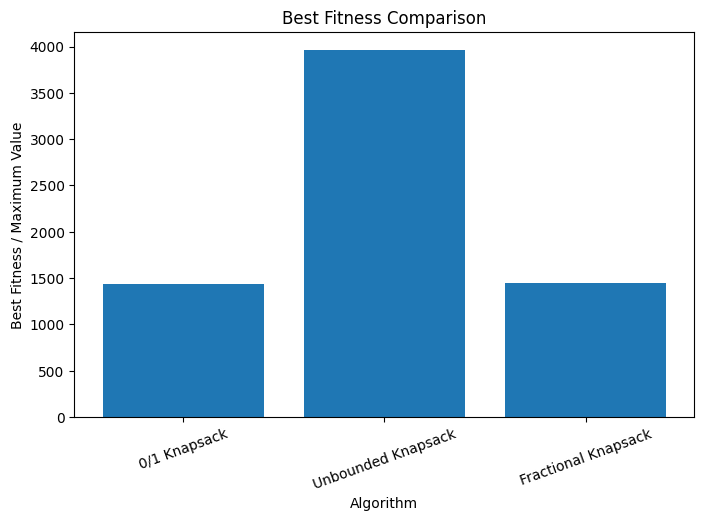

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(metrics_df["Algorithm"], metrics_df["Best Fitness"])

plt.title("Best Fitness Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Best Fitness / Maximum Value")
plt.xticks(rotation=20)

plt.show()

### Mean ve Standard Deviation Grafiği

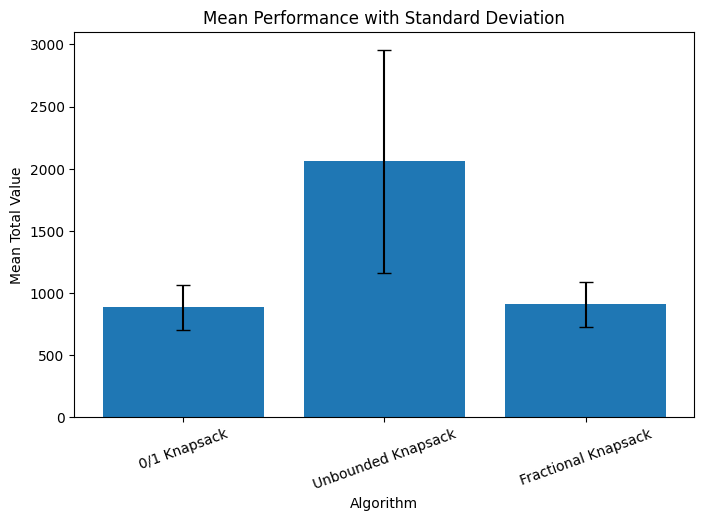

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(
    metrics_df["Algorithm"],
    metrics_df["Mean"],
    yerr=metrics_df["Standard Deviation"],
    capsize=5
)

plt.title("Mean Performance with Standard Deviation")
plt.xlabel("Algorithm")
plt.ylabel("Mean Total Value")
plt.xticks(rotation=20)

plt.show()

##  Convergence Analysis

Bu analizde 0/1 Knapsack algoritmasının işlenen ürün sayısına göre ulaştığı en iyi çözüm değeri incelenmiştir.

Amaç, algoritmanın optimum çözüme nasıl yaklaştığını gözlemlemektir.

In [24]:
def zero_one_convergence(weights, values, capacity):

    n = len(weights)

    dp = [[0 for _ in range(capacity + 1)]
          for _ in range(n + 1)]

    convergence = []

    for i in range(1, n + 1):

        for w in range(capacity + 1):

            if weights[i - 1] <= w:

                dp[i][w] = max(
                    values[i - 1] + dp[i - 1][w - weights[i - 1]],
                    dp[i - 1][w]
                )

            else:

                dp[i][w] = dp[i - 1][w]

        convergence.append(dp[i][capacity])

    return convergence

In [25]:
conv_01 = zero_one_convergence(
    weights,
    values,
    capacity
)

conv_01

[26,
 189,
 259,
 445,
 618,
 777,
 904,
 910,
 910,
 910,
 944,
 944,
 944,
 1102,
 1162,
 1199,
 1199,
 1199,
 1199,
 1199]

Yakınsama (Convergence) analizi yalnızca 0/1 Knapsack algoritması için gerçekleştirilmiştir. Bunun nedeni 0/1 Knapsack'ın Dynamic Programming yapısında ürünler adım adım işlendiğinden, her adımda elde edilen en iyi çözüm değerinin izlenebilmesidir. Unbounded Knapsack ve Fractional Knapsack algoritmaları ise farklı çalışma mantıklarına sahip olduğundan klasik anlamda benzer bir yakınsama süreci göstermemektedir. Bu nedenle yakınsama davranışını incelemek için 0/1 Knapsack algoritması tercih edilmiştir.

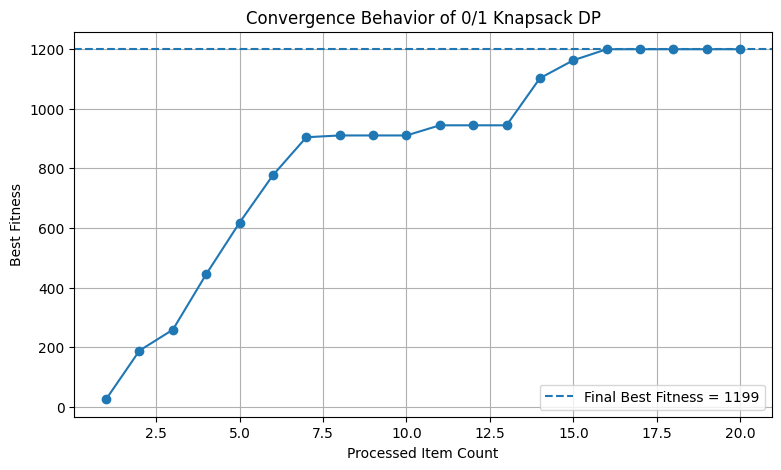

In [27]:
final_value = conv_01[-1]

plt.figure(figsize=(9,5))

plt.plot(
    range(1, len(conv_01)+1),
    conv_01,
    marker='o'
)

plt.axhline(
    y=final_value,
    linestyle='--',
    label=f'Final Best Fitness = {final_value}'
)

plt.xlabel("Processed Item Count")

plt.ylabel("Best Fitness")

plt.title(
    "Convergence Behavior of 0/1 Knapsack DP"
)

plt.legend()

plt.grid(True)

plt.show()

Şekil incelendiğinde 0/1 Knapsack algoritmasının çözüm değerinin ürün sayısı arttıkça düzenli olarak yükseldiği ve 16. üründen sonra 1199 değerinde sabitlendiği görülmektedir. Bu durum algoritmanın optimum çözüme ulaştığını ve sonraki ürünlerin mevcut çözümü iyileştiremediğini göstermektedir. Grafik, Dynamic Programming yaklaşımının kararlı ve sistematik şekilde optimum çözüme yakınsadığını ortaya koymaktadır.

##  Function Evaluation Analysis

Bu analizde algoritmaların teorik olarak gerçekleştirdiği işlem sayıları karşılaştırılmıştır.

Function Evaluation değeri, algoritmanın problem çözümü sırasında değerlendirdiği durum sayısını temsil etmektedir.

Daha düşük değerler, daha düşük hesaplama maliyetine işaret etmektedir.

In [28]:
def function_evaluation_counts(n_items, capacity):

    eval_01 = n_items * capacity

    eval_unbounded = n_items * capacity

    eval_fractional = n_items * np.log2(n_items)

    return (
        eval_01,
        eval_unbounded,
        eval_fractional
    )

In [29]:
eval_01, eval_unbounded, eval_fractional = \
function_evaluation_counts(
    n_items,
    capacity
)

function_eval_df = pd.DataFrame({
    "Algorithm": [
        "0/1 Knapsack",
        "Unbounded Knapsack",
        "Fractional Knapsack"
    ],
    "Estimated Function Evaluation": [
        eval_01,
        eval_unbounded,
        eval_fractional
    ]
})

function_eval_df

,Algorithm,Estimated Function Evaluation
0,0/1 Knapsack,2000.000000
1,Unbounded Knapsack,2000.000000
2,Fractional Knapsack,86.438562


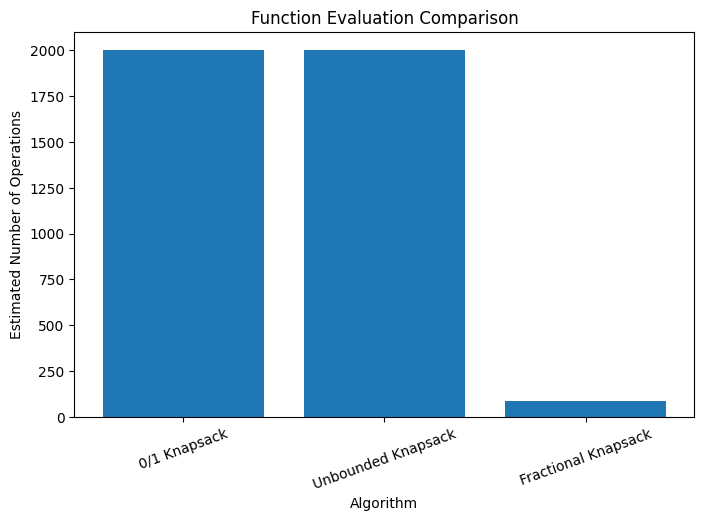

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    function_eval_df["Algorithm"],
    function_eval_df["Estimated Function Evaluation"]
)

plt.title(
    "Function Evaluation Comparison"
)

plt.xlabel("Algorithm")

plt.ylabel(
    "Estimated Number of Operations"
)

plt.xticks(rotation=20)

plt.show()

Function Evaluation analizi kapsamında algoritmaların teorik işlem maliyetleri karşılaştırılmıştır. 0/1 Knapsack ve Unbounded Knapsack algoritmaları yaklaşık O(n×W) karmaşıklığında çalıştıkları için benzer sayıda durum değerlendirmesi gerçekleştirmiştir. Fractional Knapsack algoritması ise O(n log n) karmaşıklığında çalışan greedy yaklaşım kullandığından çok daha düşük işlem sayısına ihtiyaç duymuştur. Sonuçlar, Fractional Knapsack algoritmasının hesaplama maliyeti açısından en verimli yöntem olduğunu göstermektedir.

### Sensitivity Analysis

Bu analizde kapasite değerinin algoritmaların elde ettiği çözüm kalitesi üzerindeki etkisi incelenmiştir.

Kapasite arttıkça algoritmaların nasıl tepki verdiği ve çözüm değerlerinin nasıl değiştiği gözlemlenmiştir.

In [31]:
capacity_values = [20, 40, 60, 80, 100, 150, 200]

sensitivity_results = []

for cap in capacity_values:

    result_01, _ = zero_one_knapsack(
        weights,
        values,
        cap
    )

    result_unbounded, _ = unbounded_knapsack(
        weights,
        values,
        cap
    )

    result_fractional, _ = fractional_knapsack(
        weights,
        values,
        cap
    )

    sensitivity_results.append({
        "Capacity": cap,
        "0/1 Knapsack": result_01,
        "Unbounded Knapsack": result_unbounded,
        "Fractional Knapsack": round(result_fractional,2)
    })

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

sensitivity_df

,Capacity,0/1 Knapsack,Unbounded Knapsack,Fractional Knapsack
0,20,396,524,421.08
1,40,616,1048,655.30
2,60,825,1584,855.05
3,80,1024,2178,1046.60
4,100,1199,2772,1218.27
5,150,1525,4158,1574.78
6,200,1765,5544,1786.74


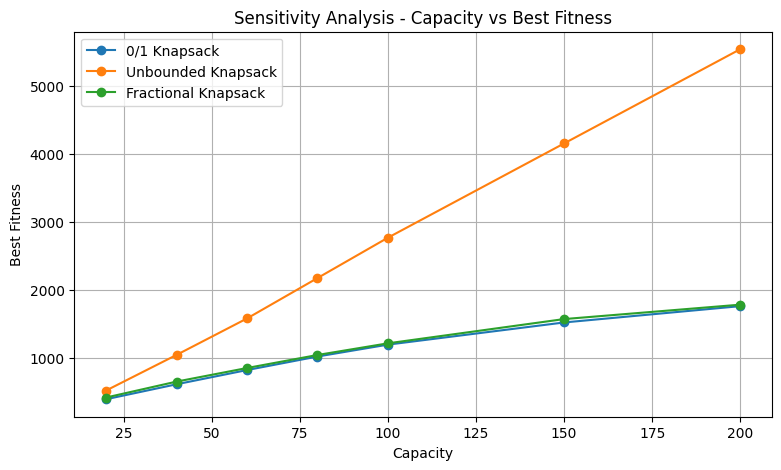

In [32]:
plt.figure(figsize=(9,5))

plt.plot(
    sensitivity_df["Capacity"],
    sensitivity_df["0/1 Knapsack"],
    marker="o",
    label="0/1 Knapsack"
)

plt.plot(
    sensitivity_df["Capacity"],
    sensitivity_df["Unbounded Knapsack"],
    marker="o",
    label="Unbounded Knapsack"
)

plt.plot(
    sensitivity_df["Capacity"],
    sensitivity_df["Fractional Knapsack"],
    marker="o",
    label="Fractional Knapsack"
)

plt.title(
    "Sensitivity Analysis - Capacity vs Best Fitness"
)

plt.xlabel("Capacity")

plt.ylabel("Best Fitness")

plt.legend()

plt.grid(True)

plt.show()

0/1 Knapsack

      Mavi çizgi düzenli şekilde yükseliyor.

      Sebebi:

      Kapasite arttıkça daha fazla ürün seçilebiliyor.
      Ancak her ürün yalnızca bir kez seçilebildiği için büyüme sınırlı kalıyor.

Fractional Knapsack

      Yeşil çizgi 0/1'e çok yakın.

      Hatta çoğu noktada biraz daha yukarıda.

      Sebebi:

      Ürünler parçalanabiliyor. Kapasitenin son kısmı daha verimli kullanılabiliyor.

      Bu yüzden:

      Fractional > 0/1 çıkması beklenen bir sonuç.

Unbounded Knapsack

      Turuncu çizgi çok daha hızlı yükseliyor.

      Sebebi:

      Aynı üründen tekrar tekrar alınabiliyor.
      Özellikle değer/ağırlık oranı yüksek ürünler bulunduğunda kapasite artışı doğrudan toplam değere yansıyor.

      Bu nedenle:

      Kapasite arttıkça Toplam Değer çok hızlı atmış oluyor.

Şekilde kapasite değişiminin algoritmaların çözüm kalitesi üzerindeki etkisi gösterilmektedir. Kapasite arttıkça tüm algoritmaların elde ettiği çözüm değerleri yükselmiştir. Ancak artış oranları farklılık göstermektedir. Unbounded Knapsack algoritması aynı üründen birden fazla seçime izin verdiği için kapasite artışına en duyarlı algoritma olmuş ve en yüksek çözüm değerlerini elde etmiştir. Fractional Knapsack algoritması ürünlerin parçalı olarak seçilebilmesi sayesinde 0/1 Knapsack algoritmasından biraz daha yüksek performans göstermiştir. Sonuçlar kapasite değişiminin algoritmalar üzerinde farklı etkiler oluşturduğunu ve özellikle Unbounded Knapsack algoritmasının kapasite artışından en fazla faydalanan yöntem olduğunu göstermektedir.

## Scalability Analysis

Bu analizde ürün sayısının algoritmaların çalışma süresi üzerindeki etkisi incelenmiştir.

Amaç, problem boyutu büyüdükçe algoritmaların ne kadar ölçeklenebilir olduğunu değerlendirmektir.

In [33]:
item_sizes = [10, 20, 50, 100, 200, 500]

scalability_results = []

In [34]:
for n in item_sizes:

    w, v = generate_random_data(n)

    t01 = measure_time(
        zero_one_knapsack,
        w,
        v,
        capacity
    )

    tunb = measure_time(
        unbounded_knapsack,
        w,
        v,
        capacity
    )

    tfrac = measure_time(
        fractional_knapsack,
        w,
        v,
        capacity
    )

    scalability_results.append({
        "Items": n,
        "0/1": t01,
        "Unbounded": tunb,
        "Fractional": tfrac
    })

scalability_df = pd.DataFrame(
    scalability_results
)

scalability_df

,Items,0/1,Unbounded,Fractional
0,10,0.000283,0.000105,0.000006
1,20,0.000555,0.000189,0.000009
2,50,0.001411,0.000464,0.000020
3,100,0.002878,0.000906,0.000041
4,200,0.007965,0.001760,0.000087
5,500,0.017724,0.006351,0.000235


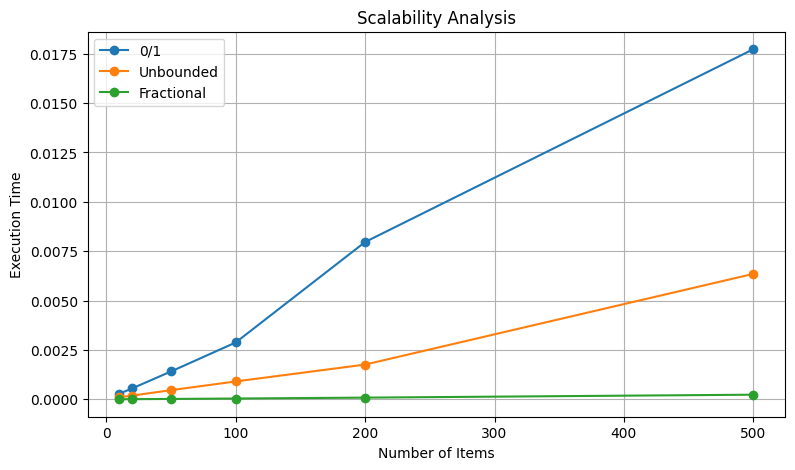

In [35]:
plt.figure(figsize=(9,5))

plt.plot(
    scalability_df["Items"],
    scalability_df["0/1"],
    marker="o",
    label="0/1"
)

plt.plot(
    scalability_df["Items"],
    scalability_df["Unbounded"],
    marker="o",
    label="Unbounded"
)

plt.plot(
    scalability_df["Items"],
    scalability_df["Fractional"],
    marker="o",
    label="Fractional"
)

plt.title(
    "Scalability Analysis"
)

plt.xlabel(
    "Number of Items"
)

plt.ylabel(
    "Execution Time"
)

plt.legend()

plt.grid(True)

plt.show()

Şekilde ürün sayısının algoritmaların çalışma süreleri üzerindeki etkisi gösterilmektedir. Ürün sayısı arttıkça tüm algoritmaların çalışma süreleri yükselmiştir. Ancak artış oranları farklılık göstermektedir. Fractional Knapsack algoritması tüm problem boyutlarında en düşük çalışma süresine sahip olmuş ve en iyi ölçeklenebilirliği göstermiştir. Unbounded Knapsack algoritması orta seviyede bir artış sergilerken, 0/1 Knapsack algoritması en yüksek çalışma süresine ulaşmıştır. Sonuçlar teorik zaman karmaşıklıkları ile uyumlu olup, problem boyutu büyüdükçe greedy yaklaşımın daha avantajlı olduğunu göstermektedir.

In [36]:
complexity_df = pd.DataFrame({
    "Algorithm": [
        "0/1 Knapsack",
        "Unbounded Knapsack",
        "Fractional Knapsack"
    ],
    "Theoretical Complexity": [
        "O(nW)",
        "O(nW)",
        "O(n log n)"
    ]
})

complexity_df

,Algorithm,Theoretical Complexity
0,0/1 Knapsack,O(nW)
1,Unbounded Knapsack,O(nW)
2,Fractional Knapsack,O(n log n)


##  Statistical Analysis

Bu bölümde algoritmaların performansları istatistiksel olarak karşılaştırılmıştır.

Karşılaştırma için parametrik olmayan Friedman Testi kullanılmıştır.

Hipotezler:

H0: Algoritmalar arasında anlamlı fark yoktur.

H1: En az bir algoritma diğerlerinden farklı performans göstermektedir.

### Friedman Testi

In [37]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(
    analysis_df["0/1 Knapsack"],
    analysis_df["Unbounded Knapsack"],
    analysis_df["Fractional Knapsack"]
)

print("Friedman Statistic:", stat)
print("p-value:", p)

Friedman Statistic: 59.51260504201679
p-value: 1.193993639511826e-13


In [38]:
rank_df = analysis_df.drop(
    columns=["Run"]
).rank(
    axis=1,
    ascending=False
)

average_ranks = rank_df.mean()

average_ranks

,0
0/1 Knapsack,2.983333
Unbounded Knapsack,1.000000
Fractional Knapsack,2.016667


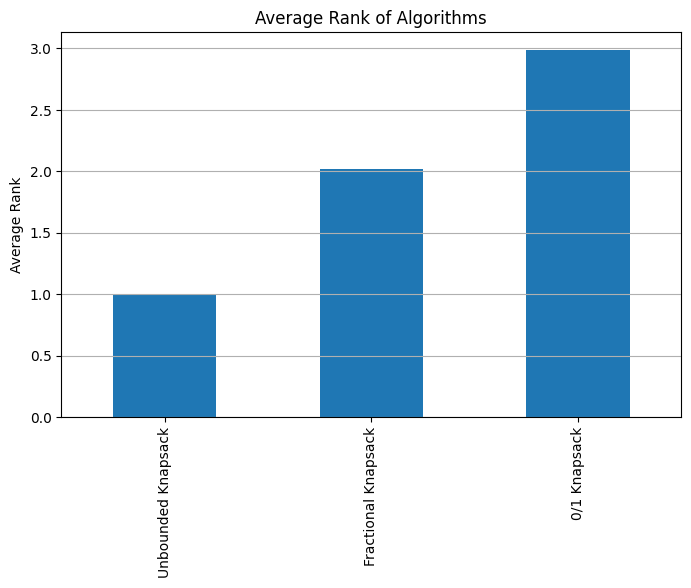

In [39]:
plt.figure(figsize=(8,5))

average_ranks.sort_values().plot(
    kind="bar"
)

plt.title(
    "Average Rank of Algorithms"
)

plt.ylabel(
    "Average Rank"
)

plt.grid(axis="y")

plt.show()

In [40]:
if p < 0.05:
    print(
        "Algoritmalar arasında istatistiksel olarak anlamlı fark vardır."
    )
else:
    print(
        "Algoritmalar arasında istatistiksel olarak anlamlı fark yoktur."
    )

Algoritmalar arasında istatistiksel olarak anlamlı fark vardır.


Friedman testi sonucunda p-değeri 1.19×10⁻¹³ olarak elde edilmiştir. Bu değer 0.05 anlamlılık seviyesinden oldukça küçük olduğundan sıfır hipotezi reddedilmiştir. Sonuç olarak algoritmalar arasında istatistiksel olarak anlamlı performans farkları bulunduğu belirlenmiştir. Ortalama sıralamalar incelendiğinde Unbounded Knapsack algoritmasının en başarılı yöntem olduğu görülmektedir. Fractional Knapsack ikinci sırada yer alırken, 0/1 Knapsack üçüncü sırada bulunmaktadır. Bu sonuçlar Best Fitness ve Mean Performance analizleri ile uyumludur.

## Diversity Analysis

Bu analizde veri setindeki ürünlerin ağırlık ve değer çeşitliliği incelenmiştir.

Çeşitlilik ölçütü olarak standart sapma (Standard Deviation) kullanılmıştır.

Yüksek standart sapma, ürünlerin birbirinden daha farklı olduğunu göstermektedir.

In [41]:
weights_array = np.array(weights)

values_array = np.array(values)

weight_diversity = np.std(weights_array)

value_diversity = np.std(values_array)

print("Weight Diversity (STD):", weight_diversity)

print("Value Diversity (STD):", value_diversity)

Weight Diversity (STD): 14.154416271962614
Value Diversity (STD): 52.98122308893973


In [42]:
diversity_df = pd.DataFrame({
    "Feature": [
        "Weights",
        "Values"
    ],
    "Standard Deviation": [
        weight_diversity,
        value_diversity
    ]
})

diversity_df

,Feature,Standard Deviation
0,Weights,14.154416
1,Values,52.981223


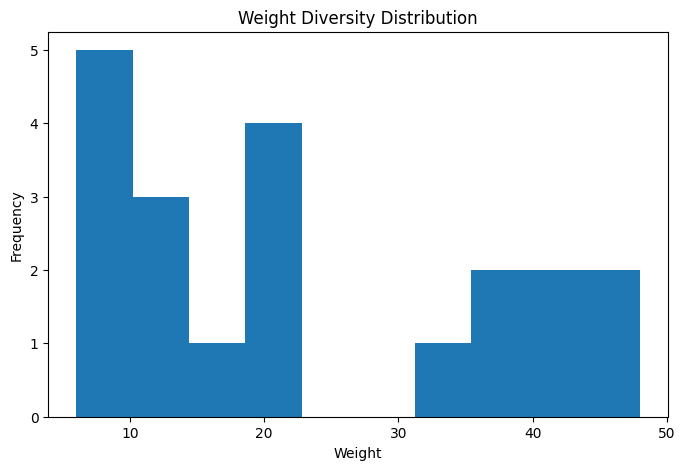

In [43]:
plt.figure(figsize=(8,5))

plt.hist(
    weights_array,
    bins=10
)

plt.title(
    "Weight Diversity Distribution"
)

plt.xlabel("Weight")

plt.ylabel("Frequency")

plt.show()

Şekil, ürün ağırlıklarının dağılımını göstermektedir. Ağırlıklar yaklaşık 5 ile 50 arasında değişmekte olup ürünlerin önemli bir kısmı düşük ve orta ağırlık aralıklarında yoğunlaşmaktadır. Hesaplanan 14.15 standart sapma değeri, veri setinde orta seviyede ağırlık çeşitliliği bulunduğunu göstermektedir. Bu çeşitlilik sayesinde algoritmalar farklı ağırlıklara sahip ürünler arasında seçim yapmak zorunda kalmış ve kapasite kısıtı altında farklı çözüm stratejileri geliştirmiştir.

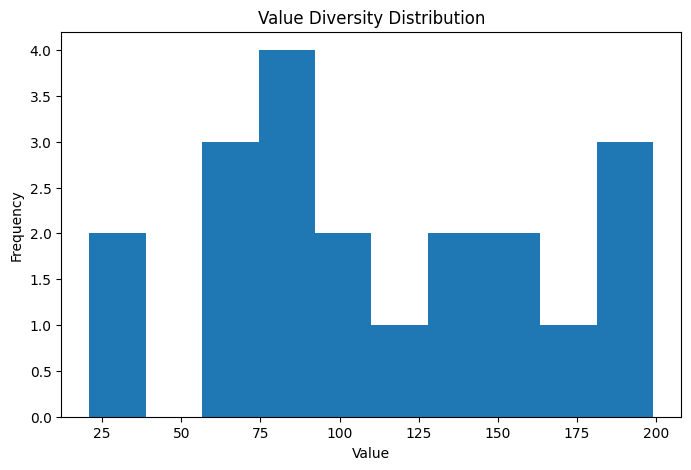

In [44]:
plt.figure(figsize=(8,5))

plt.hist(
    values_array,
    bins=10
)

plt.title(
    "Value Diversity Distribution"
)

plt.xlabel("Value")

plt.ylabel("Frequency")

plt.show()

Şekil, ürün değerlerinin dağılımını göstermektedir. Ürün değerleri yaklaşık 20 ile 200 arasında geniş bir aralığa yayılmıştır. Dağılımın tek bir bölgede yoğunlaşmaması ve standart sapma değerinin 52.98 olması, veri setinin yüksek değer çeşitliliğine sahip olduğunu göstermektedir. Bu çeşitlilik algoritmaların farklı ürün kombinasyonları arasında seçim yapmasını gerektirmiş ve performans farklılıklarının daha belirgin şekilde ortaya çıkmasına katkı sağlamıştır.

In [45]:
conclusion_df = pd.DataFrame({
    "Evaluation Criterion": [
        "Best Fitness",
        "Mean Performance",
        "Stability (Robustness)",
        "Computational Cost",
        "Scalability",
        "Statistical Ranking"
    ],
    "Best Algorithm": [
        "Unbounded Knapsack",
        "Unbounded Knapsack",
        "Fractional Knapsack",
        "Fractional Knapsack",
        "Fractional Knapsack",
        "Unbounded Knapsack"
    ]
})

conclusion_df

,Evaluation Criterion,Best Algorithm
0,Best Fitness,Unbounded Knapsack
1,Mean Performance,Unbounded Knapsack
2,Stability (Robustness),Fractional Knapsack
3,Computational Cost,Fractional Knapsack
4,Scalability,Fractional Knapsack
5,Statistical Ranking,Unbounded Knapsack


##  General Conclusion

Bu çalışmada 0/1 Knapsack, Unbounded Knapsack ve Fractional Knapsack algoritmaları aynı veri setleri üzerinde karşılaştırılmıştır.

Elde edilen sonuçlara göre:

- Unbounded Knapsack algoritması en yüksek çözüm kalitesini sağlamıştır.
- Fractional Knapsack algoritması en düşük hesaplama maliyetine ve en iyi ölçeklenebilirliğe sahip olmuştur.
- 0/1 Knapsack algoritması daha kısıtlı bir problem yapısına sahip olduğundan çözüm kalitesi açısından diğer yöntemlerin gerisinde kalmıştır.
- Friedman testi algoritmalar arasında istatistiksel olarak anlamlı farklar bulunduğunu göstermiştir.

Sonuç olarak çözüm kalitesinin öncelikli olduğu durumlarda Unbounded Knapsack, çalışma süresi ve hesaplama maliyetinin önemli olduğu durumlarda ise Fractional Knapsack algoritması tercih edilebilir.